In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import os
import random
import time
import warnings
warnings.filterwarnings('ignore')

# ── Numerical & Data Handling ────────────────────────────────────────────────
import numpy as np
import scipy.io as sio          # For loading .mat files
import h5py                      # For newer v7.3 .mat files
import pandas as pd

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── PyTorch Core ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# ── Torchvision (ResNet101 + Transforms) ────────────────────────────────────
import torchvision.transforms as T
from torchvision.models import resnet101, ResNet101_Weights

# ── Sklearn Metrics ──────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.preprocessing import label_binarize

# ── PIL ───────────────────────────────────────────────────────────────────────
from PIL import Image

# ── Set Seeds for Reproducibility ────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

print("All libraries imported successfully!")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version : 2.10.0+cu128
CUDA available  : True


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# All tunable hyperparameters in one place.
# ─────────────────────────────────────────────────────────────────────────────

# Dataset root — Kaggle input directory
DATA_DIR  = "/kaggle/input/datasets/userisakid/augmented-figshare-dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# Class names — must match subfolder names inside train/val/test
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)

# Image settings
IMG_SIZE      = 224          # ResNet101 default input size

# Training settings
BATCH_SIZE    = 32
NUM_EPOCHS    = 30           # Max epochs (early stopping may halt sooner)
LEARNING_RATE = 1e-4         # Initial LR for unfrozen layers
WEIGHT_DECAY  = 1e-4         # L2 regularization

# Augmentation settings
CROP_SCALE    = (0.8, 1.0)   # RandomResizedCrop zoom range
CROP_RATIO    = (0.75, 1.33) # Aspect ratio range
ERASING_PROB  = 0.5          # RandomErasing probability
ERASING_SCALE = (0.02, 0.10) # Fraction of image area to erase
ERASING_RATIO = (0.3, 3.3)   # Aspect ratio of erased patch

# Early stopping
PATIENCE      = 7            # Stop if val acc doesn't improve for 7 epochs

# Scheduler
LR_STEP_SIZE  = 7            # Decay LR every 7 epochs
LR_GAMMA      = 0.5          # Multiply LR by this factor

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device         : {DEVICE}")
print(f"Num classes    : {NUM_CLASSES}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Max epochs     : {NUM_EPOCHS}")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Early stopping : patience = {PATIENCE} epochs")
print(f"\nDirectories:")
print(f"  Train : {TRAIN_DIR}")
print(f"  Val   : {VAL_DIR}")
print(f"  Test  : {TEST_DIR}")

Device         : cuda
Num classes    : 4
Batch size     : 32
Max epochs     : 30
Learning rate  : 0.0001
Early stopping : patience = 7 epochs

Directories:
  Train : /kaggle/input/datasets/userisakid/augmented-figshare-dataset/train
  Val   : /kaggle/input/datasets/userisakid/augmented-figshare-dataset/val
  Test  : /kaggle/input/datasets/userisakid/augmented-figshare-dataset/test


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset layout:
#   <split>/<class>/<file>.mat
# where split ∈ {train, val, test}
#       class ∈ {glioma, meningioma, no_tumor, pituitary}}
# This cell scans each split and reports image counts per class.
# ─────────────────────────────────────────────────────────────────────────────

def count_mat_files(split_dir, class_names):
    counts = {}
    for cls in class_names:
        cls_dir = os.path.join(split_dir, cls)
        if os.path.isdir(cls_dir):
            n = sum(1 for f in os.listdir(cls_dir) if f.endswith('.mat'))
            counts[cls] = n
        else:
            print(f"⚠️  Missing folder: {cls_dir}")
            counts[cls] = 0
    return counts

train_counts = count_mat_files(TRAIN_DIR, CLASS_NAMES)
val_counts   = count_mat_files(VAL_DIR,   CLASS_NAMES)
test_counts  = count_mat_files(TEST_DIR,  CLASS_NAMES)

print(f"{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 52)
for cls in CLASS_NAMES:
    tot = train_counts[cls] + val_counts[cls] + test_counts[cls]
    print(f"{cls:<20} {train_counts[cls]:>8} {val_counts[cls]:>8} {test_counts[cls]:>8} {tot:>8}")

total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())
grand_total = total_train + total_val + total_test
print("-" * 52)
print(f"{'TOTAL':<20} {total_train:>8} {total_val:>8} {total_test:>8} {grand_total:>8}")

Class                   Train      Val     Test    Total
----------------------------------------------------
glioma                   2520      140      140     2800
meningioma               2520      140      140     2800
no_tumor                 2520      140      140     2800
pituitary                2520      140      140     2800
----------------------------------------------------
TOTAL                   10080      560      560    11200


In [4]:
def load_mat_image(filepath):
    """
    Load a brain MRI image from a .mat file.
    Handles both old MATLAB format (scipy) and newer v7.3 (h5py).
    Returns a numpy array (H, W) with values in [0, 255].
    """
    try:
        # Try scipy first (works for most .mat files)
        mat = sio.loadmat(filepath)
        img = mat['cjdata']['image'][0, 0].astype(np.float32)
    except Exception:
        # Fallback: newer v7.3 .mat format uses HDF5
        with h5py.File(filepath, 'r') as f:
            img = np.array(f['cjdata']['image']).astype(np.float32)
            img = img.T   # Transpose because h5py stores in C-order

    # Normalize to [0, 255] uint8
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min) * 255.0
    img = img.astype(np.uint8)
    return img


# ── Build file lists from the pre-split folders ──────────────────────────────

def build_file_list(split_dir, class_names):
    """
    Walk split_dir/<class>/*.mat and return a list of (filepath, label_idx).
    """
    file_list = []
    for label_idx, cls in enumerate(class_names):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            if fname.endswith('.mat'):
                file_list.append((os.path.join(cls_dir, fname), label_idx))
    return file_list

train_files = build_file_list(TRAIN_DIR, CLASS_NAMES)
val_files   = build_file_list(VAL_DIR,   CLASS_NAMES)
test_files  = build_file_list(TEST_DIR,  CLASS_NAMES)

print(f"Train samples : {len(train_files)}")
print(f"Val   samples : {len(val_files)}")
print(f"Test  samples : {len(test_files)}")
print(f"Total samples : {len(train_files)+len(val_files)+len(test_files)}")

Train samples : 10080
Val   samples : 560
Test  samples : 560
Total samples : 11200


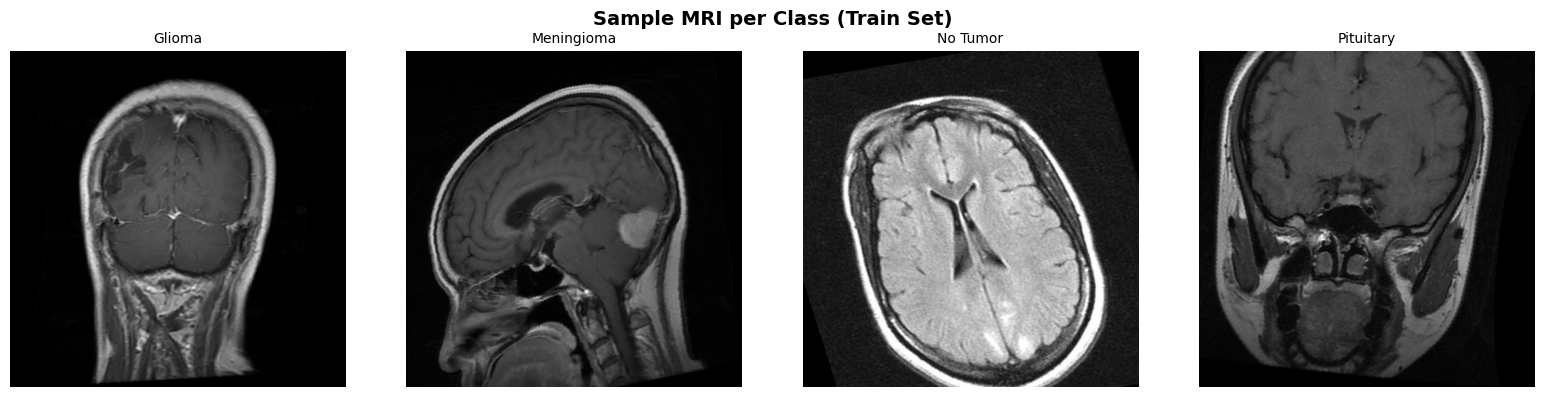

In [5]:
# Show one sample image from each class to confirm loading works correctly.

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
fig.suptitle("Sample MRI per Class (Train Set)", fontsize=14, fontweight='bold')

for label_idx, (ax, cls) in enumerate(zip(axes, CLASS_NAMES)):
    sample_path = next(fp for fp, lbl in train_files if lbl == label_idx)
    img = load_mat_image(sample_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(cls.replace('_', ' ').title(), fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Custom PyTorch Dataset:
#   - Loads .mat files on-the-fly
#   - Converts grayscale MRI → 3-channel RGB (ResNet101 expects 3 channels)
#   - Applies transforms (augmentation for train, basic resize for val/test)
# ─────────────────────────────────────────────────────────────────────────────

class BrainTumorDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filepath, label = self.file_list[idx]
        img_np  = load_mat_image(filepath)
        # Convert grayscale → RGB (ResNet101 expects 3-channel input)
        pil_img = Image.fromarray(img_np, mode='L').convert('RGB')
        if self.transform:
            pil_img = self.transform(pil_img)
        return pil_img, label


# ── Define Transforms ────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# TRAIN: augmentation (RandomResizedCrop + RandomErasing)
train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomResizedCrop(
        size=IMG_SIZE,
        scale=CROP_SCALE,
        ratio=CROP_RATIO
    ),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(
        p=ERASING_PROB,
        scale=ERASING_SCALE,
        ratio=ERASING_RATIO,
        value=0
    )
])

# VAL / TEST: no augmentation
val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Dataset class and transforms defined!")
print(f"\nTrain transforms:\n{train_transforms}")
print(f"\nVal/Test transforms:\n{val_test_transforms}")

Dataset class and transforms defined!

Train transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.33), interpolation=bilinear, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0, inplace=False)
)

Val/Test transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [7]:
train_dataset = BrainTumorDataset(train_files, transform=train_transforms)
val_dataset   = BrainTumorDataset(val_files,   transform=val_test_transforms)
test_dataset  = BrainTumorDataset(test_files,  transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train  : {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val    : {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"Test   : {len(test_dataset)} samples, {len(test_loader)} batches")

Train  : 10080 samples, 315 batches
Val    : 560 samples, 18 batches
Test   : 560 samples, 18 batches


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Strategy: Freeze early layers (generic features).
#           Train later layers (task-specific features for MRI classification).
#
#   conv1, bn1, layer1, layer2 → FROZEN  (low-level + early residual blocks)
#   layer3, layer4             → TRAINABLE (high-level features)
#   fc                         → TRAINABLE (new 4-class head)
# ─────────────────────────────────────────────────────────────────────────────

def build_model(num_classes=NUM_CLASSES):
    weights = ResNet101_Weights.IMAGENET1K_V1
    model   = resnet101(weights=weights)

    # Freeze early layers
    frozen_prefixes = ['conv1', 'bn1', 'layer1', 'layer2']
    for name, param in model.named_parameters():
        if any(name.startswith(p) for p in frozen_prefixes):
            param.requires_grad = False
        else:
            param.requires_grad = True

    # Replace the final fully-connected head with a 4-class head
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


model = build_model(num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Print freeze status
print(f"{'Layer':<38} {'Status'}")
print("-" * 55)
seen = set()
for name, param in model.named_parameters():
    key = ".".join(name.split('.')[:2])
    if key not in seen:
        seen.add(key)
        status = "FROZEN" if not param.requires_grad else "TRAINABLE"
        print(f"{key:<38} {status}")

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n Total parameters    : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")
print(f"   Frozen parameters    : {total_params - trainable_params:,}")


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 160MB/s]


Layer                                  Status
-------------------------------------------------------
conv1.weight                           FROZEN
bn1.weight                             FROZEN
bn1.bias                               FROZEN
layer1.0                               FROZEN
layer1.1                               FROZEN
layer1.2                               FROZEN
layer2.0                               FROZEN
layer2.1                               FROZEN
layer2.2                               FROZEN
layer2.3                               FROZEN
layer3.0                               TRAINABLE
layer3.1                               TRAINABLE
layer3.2                               TRAINABLE
layer3.3                               TRAINABLE
layer3.4                               TRAINABLE
layer3.5                               TRAINABLE
layer3.6                               TRAINABLE
layer3.7                               TRAINABLE
layer3.8                               TRAINAB

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA
)


class EarlyStopping:
    """Stops training when val accuracy stops improving for `patience` epochs."""
    def __init__(self, patience=PATIENCE, save_path='best_model.pth'):
        self.patience  = patience
        self.save_path = save_path
        self.best_acc  = 0.0
        self.counter   = 0
        self.stop      = False

    def step(self, val_acc, model):
        if val_acc > self.best_acc:
            self.best_acc = val_acc
            self.counter  = 0
            torch.save(model.state_dict(), self.save_path)
            print(f"Best model saved (val_acc={val_acc:.4f})")
        else:
            self.counter += 1
            print(f"   ⏳ No improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.stop = True
                print(" Early stopping triggered!")


early_stopping = EarlyStopping(patience=PATIENCE, save_path='best_resnet101.pth')

print("Loss, optimizer, scheduler, and early stopping configured!")
print(f"   Criterion  : CrossEntropyLoss")
print(f"   Optimizer  : AdamW  (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"   Scheduler  : StepLR (step={LR_STEP_SIZE}, gamma={LR_GAMMA})")
print(f"   EarlyStop  : patience={PATIENCE}")

Loss, optimizer, scheduler, and early stopping configured!
   Criterion  : CrossEntropyLoss
   Optimizer  : AdamW  (lr=0.0001, wd=0.0001)
   Scheduler  : StepLR (step=7, gamma=0.5)
   EarlyStop  : patience=7


In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs  = model(images)
        loss     = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9} {'LR':>10}")
print("-" * 65)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    print(f"{epoch:>5} {train_loss:>12.4f} {train_acc:>10.4f} {val_loss:>10.4f} {val_acc:>9.4f} {current_lr:>10.2e}")

    early_stopping.step(val_acc, model)
    if early_stopping.stop:
        print(f"\n Training stopped at epoch {epoch}.")
        break

elapsed = time.time() - start_time
print(f"\n Training complete in {elapsed/60:.1f} minutes.")
print(f"Best Val Accuracy: {early_stopping.best_acc:.4f}")

Epoch   Train Loss  Train Acc   Val Loss   Val Acc         LR
-----------------------------------------------------------------
    1       0.1769     0.9389     0.0940    0.9643   1.00e-04
Best model saved (val_acc=0.9643)
    2       0.0693     0.9768     0.1158    0.9643   1.00e-04
   ⏳ No improvement (1/7)
    3       0.0456     0.9844     0.1434    0.9554   1.00e-04
   ⏳ No improvement (2/7)
    4       0.0375     0.9888     0.1305    0.9625   1.00e-04
   ⏳ No improvement (3/7)
    5       0.0320     0.9896     0.0848    0.9714   1.00e-04
Best model saved (val_acc=0.9714)
    6       0.0314     0.9886     0.0460    0.9893   1.00e-04
Best model saved (val_acc=0.9893)
    7       0.0301     0.9892     0.0794    0.9768   5.00e-05
   ⏳ No improvement (1/7)
    8       0.0092     0.9970     0.0812    0.9768   5.00e-05
   ⏳ No improvement (2/7)
    9       0.0074     0.9979     0.0999    0.9732   5.00e-05
   ⏳ No improvement (3/7)
   10       0.0081     0.9974     0.0699    0.9804   5.0

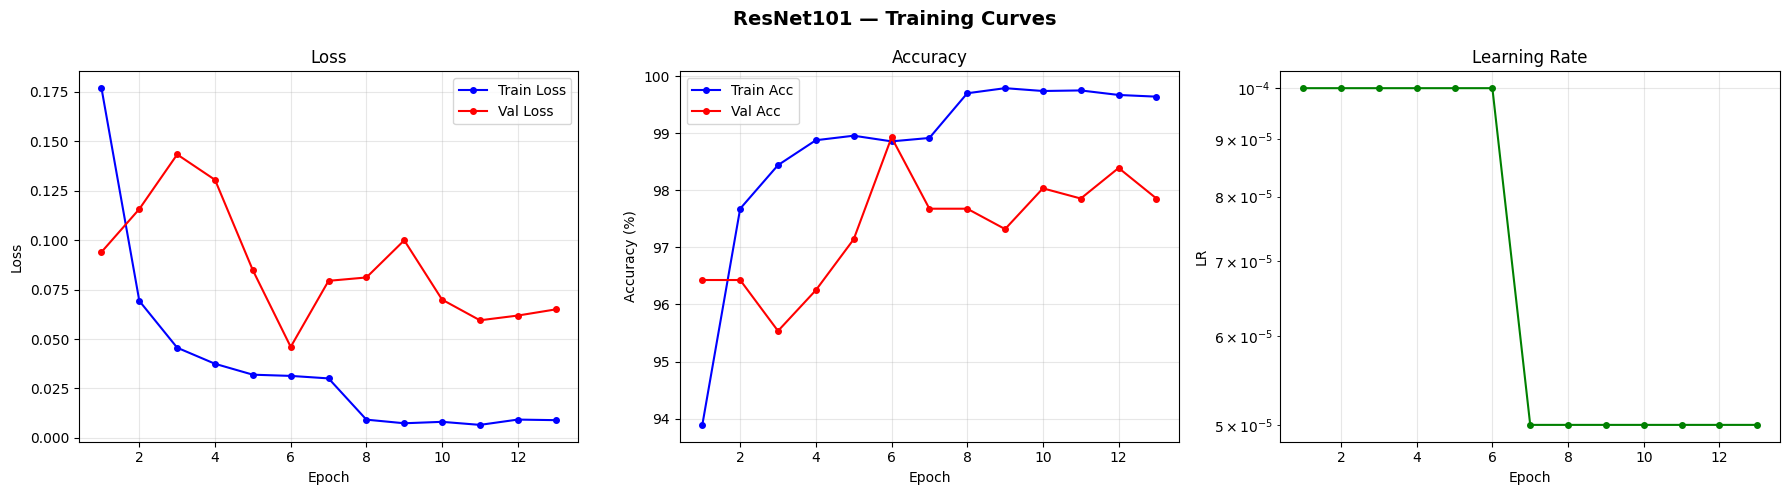

Saved training_curves.png


In [11]:
epochs_ran  = len(history['train_loss'])
epoch_range = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ResNet101 — Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(epoch_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epoch_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epoch_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epoch_range, history['lr'], 'g-o', markersize=4)
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training_curves.png")

In [12]:
model.load_state_dict(torch.load('best_resnet101.pth', map_location=DEVICE))
model.eval()
print(" Best model weights loaded.")

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

_, train_acc_final = evaluate(model, train_loader, criterion)
_, val_acc_final   = evaluate(model, val_loader,   criterion)
test_acc           = (all_preds == all_labels).mean()

print(f"\n Final Accuracies (Best Model):")
print(f"   Train Accuracy : {train_acc_final*100:.2f}%")
print(f"   Val   Accuracy : {val_acc_final*100:.2f}%")
print(f"   Test  Accuracy : {test_acc*100:.2f}%")

 Best model weights loaded.

 Final Accuracies (Best Model):
   Train Accuracy : 99.75%
   Val   Accuracy : 98.93%
   Test  Accuracy : 99.29%


In [13]:
report = classification_report(
    all_labels, all_preds,
    target_names=[c.replace('_', ' ').title() for c in CLASS_NAMES]
)
print(" Classification Report (Test Set):")
print("=" * 65)
print(report)

f1   = f1_score(all_labels, all_preds, average='weighted')
prec = precision_score(all_labels, all_preds, average='weighted')
rec  = recall_score(all_labels, all_preds, average='weighted')

print(f"Weighted F1-Score  : {f1:.4f}")
print(f"Weighted Precision : {prec:.4f}")
print(f"Weighted Recall    : {rec:.4f}")

 Classification Report (Test Set):
              precision    recall  f1-score   support

      Glioma       0.99      0.99      0.99       140
  Meningioma       0.98      0.99      0.99       140
    No Tumor       1.00      1.00      1.00       140
   Pituitary       1.00      0.99      1.00       140

    accuracy                           0.99       560
   macro avg       0.99      0.99      0.99       560
weighted avg       0.99      0.99      0.99       560

Weighted F1-Score  : 0.9929
Weighted Precision : 0.9929
Weighted Recall    : 0.9929


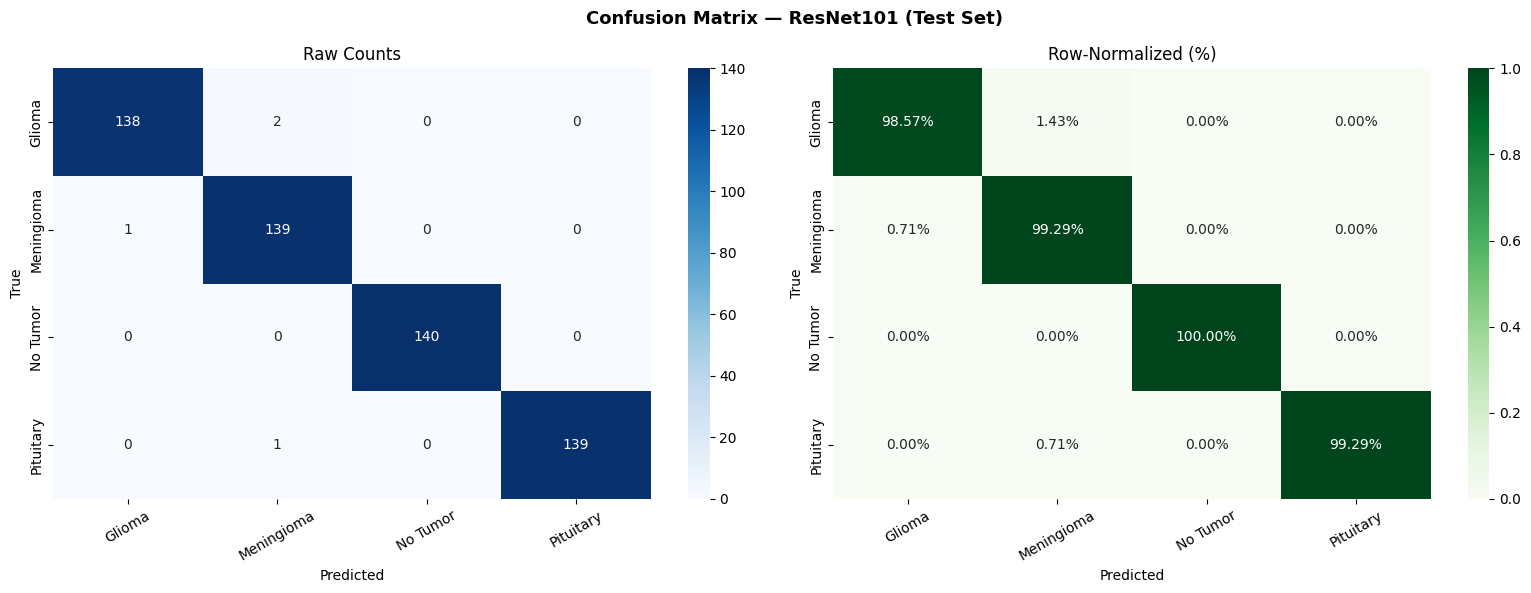

Saved confusion_matrix.png


In [14]:
cm            = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
class_labels  = [c.replace('_', ' ').title() for c in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — ResNet101 (Test Set)', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title('Raw Counts'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title('Row-Normalized (%)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrix.png")

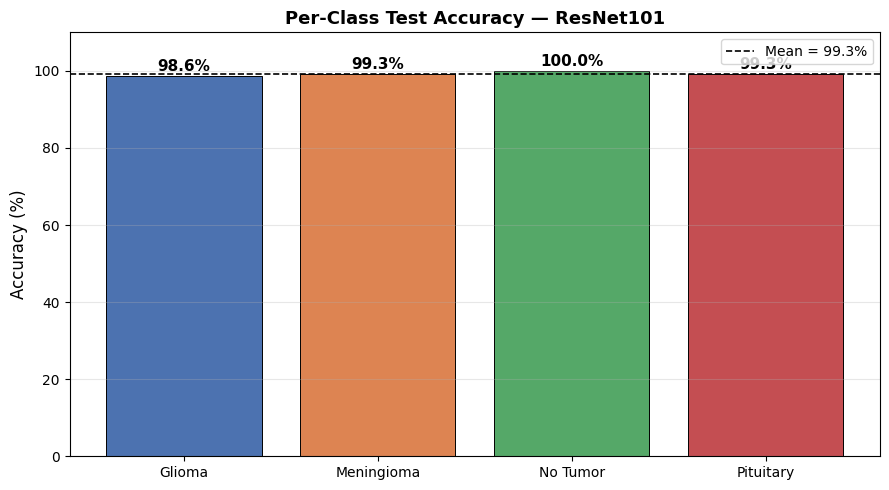

In [15]:
per_class_acc = []
for cls_idx in range(NUM_CLASSES):
    mask = (all_labels == cls_idx)
    acc  = (all_preds[mask] == all_labels[mask]).mean() if mask.sum() > 0 else 0.0
    per_class_acc.append(acc * 100)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    [c.replace('_', ' ').title() for c in CLASS_NAMES],
    per_class_acc,
    color=['#4C72B0','#DD8452','#55A868','#C44E52'],
    edgecolor='black', linewidth=0.7
)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=np.mean(per_class_acc), color='black', linestyle='--', linewidth=1.2,
           label=f'Mean = {np.mean(per_class_acc):.1f}%')
ax.set_ylim(0, 110); ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Test Accuracy — ResNet101', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

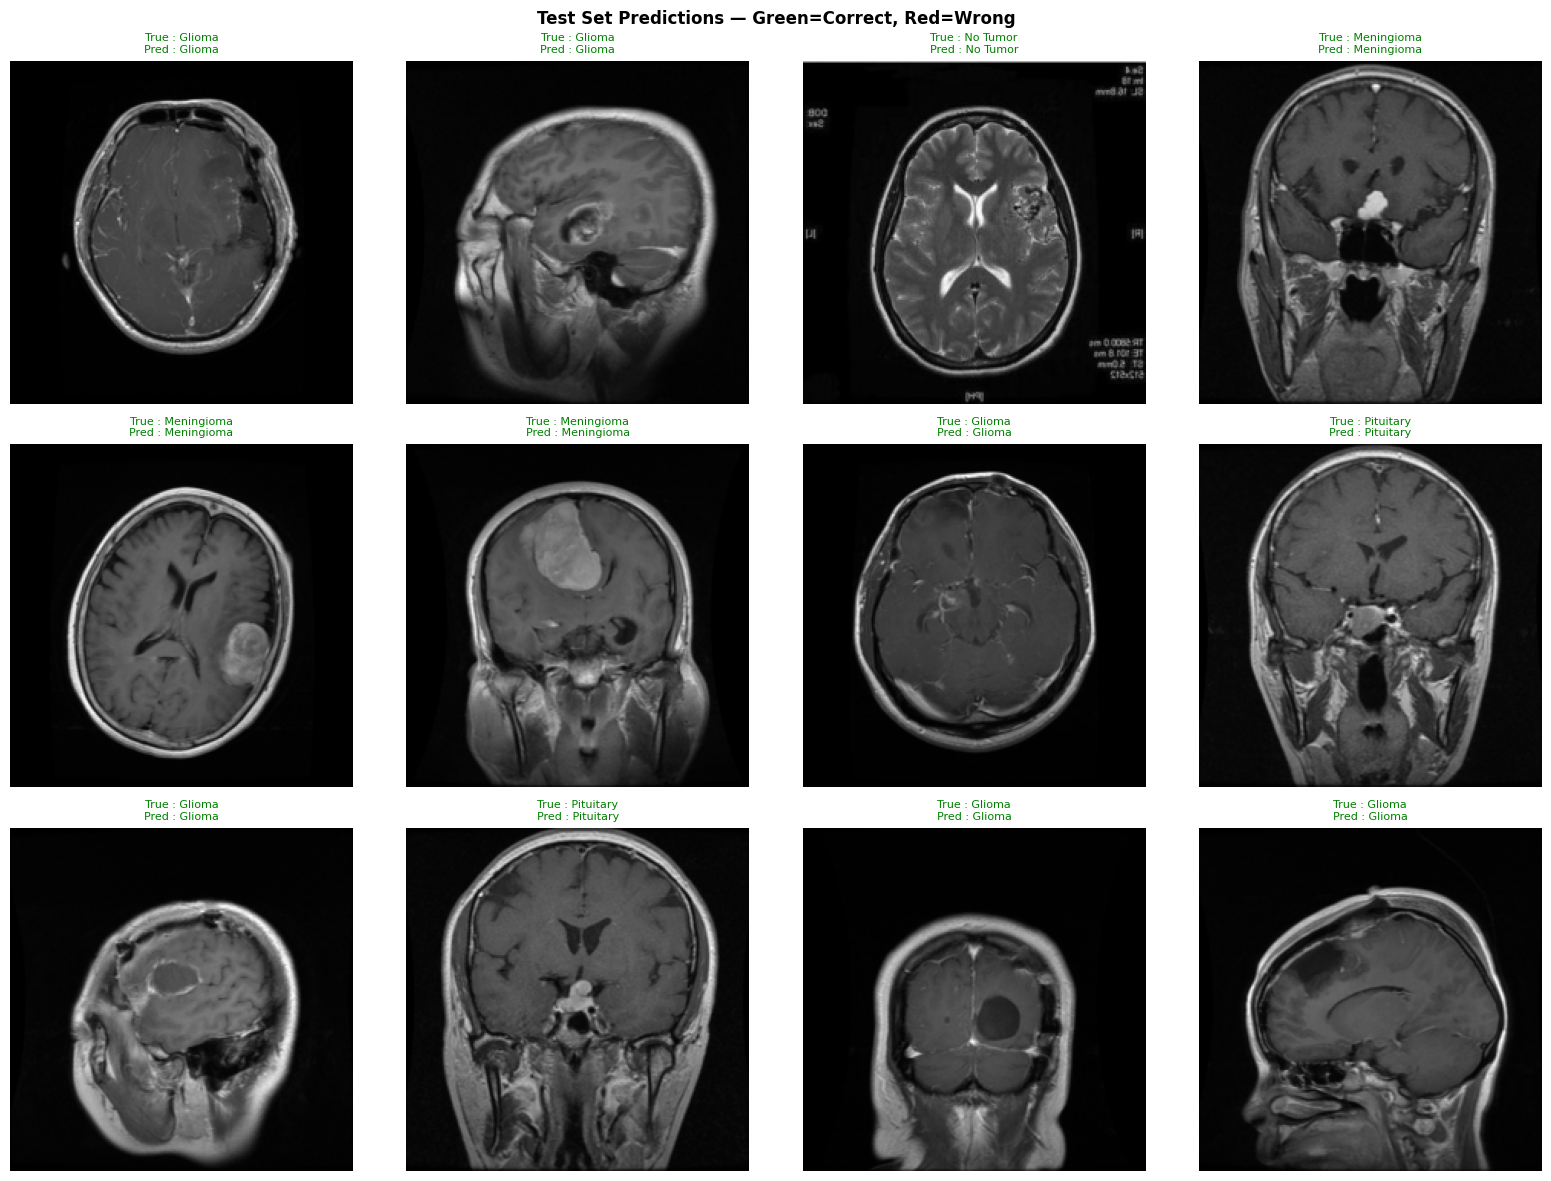

In [16]:
# Green title = correct prediction, Red = wrong.
n_samples = 12
indices   = random.sample(range(len(test_dataset)), n_samples)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Test Set Predictions — Green=Correct, Red=Wrong', fontsize=12, fontweight='bold')

for ax, idx in zip(axes.flatten(), indices):
    img_tensor, true_label = test_dataset[idx]
    with torch.no_grad():
        logits     = model(img_tensor.unsqueeze(0).to(DEVICE))
        pred_label = logits.argmax(dim=1).item()

    # Denormalize for display
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img_display = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    ax.imshow(img_display[:, :, 0], cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(
        f"True : {CLASS_NAMES[true_label].replace('_',' ').title()}\n"
        f"Pred : {CLASS_NAMES[pred_label].replace('_',' ').title()}",
        color=color, fontsize=8
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()